# Clasificación de Acciones de Fútbol: Tiro vs Jugada Dividida

Este notebook implementa un pipeline completo de Deep Learning y Visión Computacional:
- Organización de un dataset binario visualmente interpretable: **Tiro / Ejecución** vs **Jugada Dividida / Disputa**.
- Modelo 1: CNN entrenada desde cero con BatchNorm y Dropout.
- Optimización con Learning Rate Scheduler (CosineAnnealingLR).
- Comparativa experimental con y sin Data Augmentation.
- Modelo 2: Transfer Learning y Fine-Tuning con ResNet-18.
- Evaluación exhaustiva: Accuracy, ROC-AUC y Brier Score (Calibración de Probabilidades).
- Interpretabilidad visual mediante Grad-CAM.

In [ ]:
import sys
import subprocess

# Lista de librerías esenciales para visión computacional, métricas y manejo de datos
packages = [
    "torch",         # Framework principal de Deep Learning
    "torchvision",   # Modelos preentrenados y transformaciones de imágenes
    "numpy",         # Operaciones matriciales
    "matplotlib",    # Gráficos y visualizaciones
    "scikit-learn",   # Métricas: ROC-AUC, Brier score, reportes y matrices
    "tqdm",          # Barras de progreso
    "pillow",        # Manipulación y lectura de imágenes
    "kaggle"         # CLI oficial para descargar datos
]

# Instalación silenciosa en el entorno de ejecución
for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

In [ ]:
import os
import shutil
from google.colab import files

# Subir interactivamente el archivo de credenciales descargado de Kaggle
print("Sube tu archivo kaggle.json:")
uploaded = files.upload()

# Crear el directorio oculto estándar donde la librería de Kaggle busca la clave
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

# Mover el archivo y otorgar permisos de lectura seguros (chmod 600)
if "kaggle.json" in uploaded:
    shutil.move("kaggle.json", os.path.join(kaggle_dir, "kaggle.json"))
    os.chmod(os.path.join(kaggle_dir, "kaggle.json"), 0o600)
    print("¡Kaggle autenticado correctamente!")
else:
    print("Verifica que el archivo subido se llame exactamente 'kaggle.json'.")

Sube tu archivo kaggle.json:


Saving kaggle.json to kaggle.json
¡Kaggle autenticado correctamente!


In [ ]:
import os
import shutil

# Descargar y descomprimir el dataset en la carpeta temporal 'soccer_raw'
!kaggle datasets download -d rishintiw/soccer-event-classification-image-data-cnn-and-llm --unzip -p soccer_raw

# Localizar la ruta interna donde residen las categorías de imágenes
raw_dir = "soccer_raw"
images_source = None
for root, dirs, files in os.walk(raw_dir):
    if "Penalty_kick" in dirs:
        images_source = root
        break

if images_source is None:
    images_source = raw_dir

# Crear las carpetas de destino con nombres semánticamente coherentes
target_dir = "dataset_futbol_binario"
os.makedirs(f"{target_dir}/tiro", exist_ok=True)
os.makedirs(f"{target_dir}/jugada_dividida", exist_ok=True)

# 1. Clase tiro: Jugador perfilado ejecutando remates / penales (300 imágenes)
tiro_src = os.path.join(images_source, "Penalty_kick")
if os.path.exists(tiro_src):
    for img in os.listdir(tiro_src)[:300]:
        if img.lower().endswith((".jpg", ".png", ".jpeg")):
            shutil.copy(os.path.join(tiro_src, img), f"{target_dir}/tiro/{img}")

# 2. Clase jugada_dividida: Forcejeo físico, barridas y disputas en el suelo (300 imágenes)
dividida_src = os.path.join(images_source, "tackle")
if os.path.exists(dividida_src):
    for img in os.listdir(dividida_src)[:300]:
        if img.lower().endswith((".jpg", ".png", ".jpeg")):
            shutil.copy(os.path.join(dividida_src, img), f"{target_dir}/jugada_dividida/{img}")

print(f"Dataset estructurado en '{target_dir}':")
print(f" - Fotos de Tiro:            {len(os.listdir(f'{target_dir}/tiro'))}")
print(f" - Fotos de Jugada Dividida: {len(os.listdir(f'{target_dir}/jugada_dividida'))}")

Dataset URL: https://www.kaggle.com/datasets/rishintiw/soccer-event-classification-image-data-cnn-and-llm
License(s): unknown
100% 1.20G/1.20G [01:07<00:00, 19.1MB/s]

Dataset estructurado en 'dataset_futbol_binario':
 - Fotos de Tiro:            294
 - Fotos de Jugada Dividida: 297


In [ ]:
import torch
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

# Transformación estándar: Redimensionar a 128x128 y normalizar con la media/std de ImageNet
transform_basic = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ImageFolder asigna etiquetas numéricas según el orden alfabético de las carpetas
dataset_full = ImageFolder(root="dataset_futbol_binario", transform=transform_basic)
class_names = dataset_full.classes
num_classes = len(class_names)
print(f"Clases detectadas ({num_classes}):", dataset_full.class_to_idx)
# jugada_dividida -> 0, tiro -> 1

# Partición determinista: 70% entrenamiento, 15% validación, 15% prueba final
total_len = len(dataset_full)
train_len = int(0.70 * total_len)
val_len = int(0.15 * total_len)
test_len = total_len - train_len - val_len

train_dataset, val_dataset, test_dataset = random_split(
    dataset_full, [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(42)  # Semilla fija para reproducibilidad
)

print(f"Particiones: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

Clases detectadas (2): {'jugada_dividida': 0, 'tiro': 1}
Particiones: Train=413, Val=88, Test=90


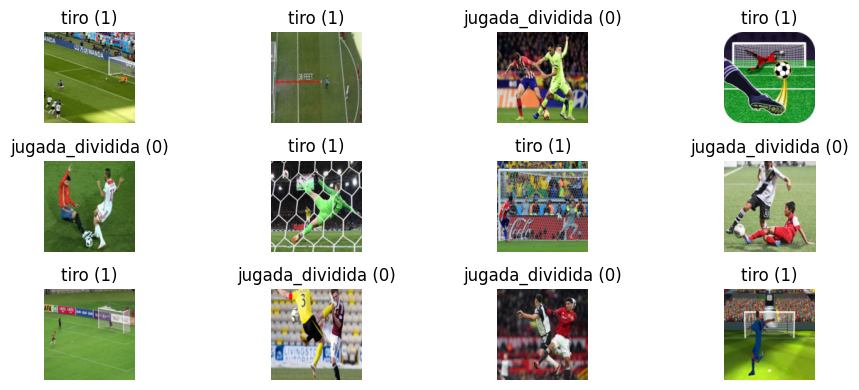

In [ ]:
import matplotlib.pyplot as plt

def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))

    # Deshacer la normalización para poder graficar los colores RGB reales de la foto
    inv_norm = T.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i + 1)
        # Permutar de formato PyTorch [C, H, W] a Matplotlib [H, W, C]
        img = inv_norm(x).permute(1, 2, 0).clamp(0, 1).numpy()
        plt.imshow(img)
        plt.title(f"{class_names[y]} ({y})")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)

In [ ]:
# Asignar GPU (CUDA) si está disponible en Colab, de lo contrario usar CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo en uso:", device)

batch_size = 32

# pin_memory acelera la transferencia de tensores de la RAM a la memoria de la GPU
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Inspeccionar las dimensiones del primer lote: [Batch, Canales, Alto, Ancho]
sample_x, sample_y = next(iter(train_loader))
print("Dimensiones por lote (X, Y):", sample_x.shape, sample_y.shape)

Dispositivo en uso: cuda
Dimensiones por lote (X, Y): torch.Size([32, 3, 128, 128]) torch.Size([32])


In [ ]:
import torch.nn as nn

class SoccerActionCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # Bloque 1: Convolución básica + BatchNorm para acelerar convergencia
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 128x128 -> 64x64

            # Bloque 2: Aumento a 64 filtros para capturar bordes y siluetas
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64x64 -> 32x32

            # Bloque 3: 128 filtros + Dropout espacial para regularizar canales
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.25),            # Apaga el 25% de los mapas convolucionales al azar
            nn.AdaptiveAvgPool2d((1, 1))   # Colapsa la resolución espacial a 1x1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),               # Dropout en la capa densa para evitar sobreajuste
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model_scratch = SoccerActionCNN(num_classes=num_classes).to(device)
model_scratch

SoccerActionCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout2d(p=0.25, inplace=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss, classification_report, confusion_matrix

@torch.no_grad()
def evaluate(model, loader):
    model.eval()  # Modo evaluación (congela BatchNorm y apaga Dropout)
    all_labels, all_probs, all_preds = [], [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device).long()
        logits = model(x)

        # Softmax convierte los logits en probabilidades continuas [0, 1]
        probs = torch.softmax(logits, dim=1)[:, 1]  # Probabilidad de clase positiva ('tiro')
        preds = torch.argmax(logits, dim=1)        # Decisión final de mayor score

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)  # Métrica de calibración (más cerca de 0 es mejor)

    return acc, auc, brier, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()  # Activa BatchNorm y Dropout para entrenar
    losses = []
    for x, y in loader:
        x, y = x.to(device), y.to(device).long()

        optimizer.zero_grad()         # Limpiar gradientes acumulados
        logits = model(x)
        loss = criterion(logits, y)  # Calcular entropía cruzada
        loss.backward()               # Propagación hacia atrás (backpropagation)
        optimizer.step()              # Actualizar pesos

        losses.append(loss.item())
    return float(np.mean(losses))

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 8
# Scheduler que reduce suavemente la tasa de aprendizaje siguiendo una curva coseno
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

history_scratch = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _, _ = evaluate(model_scratch, val_loader)

    # Actualizar la tasa de aprendizaje al final de cada época
    scheduler.step()

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Época {epoch:02d} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f} | LR: {lr_now:.6f}")

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Época 01 | Loss: 0.6386 | Val Acc: 0.6250 | Val AUC: 0.7875 | LR: 0.000962


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Época 02 | Loss: 0.5590 | Val Acc: 0.7841 | Val AUC: 0.8490 | LR: 0.000855


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Época 06 | Loss: 0.3411 | Val Acc: 0.8864 | Val AUC: 0.9581 | LR: 0.000155


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Época 07 | Loss: 0.3050 | Val Acc: 0.8977 | Val AUC: 0.9772 | LR: 0.000048


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Época 08 | Loss: 0.2963 | Val Acc: 0.8977 | Val AUC: 0.9852 | LR: 0.000010


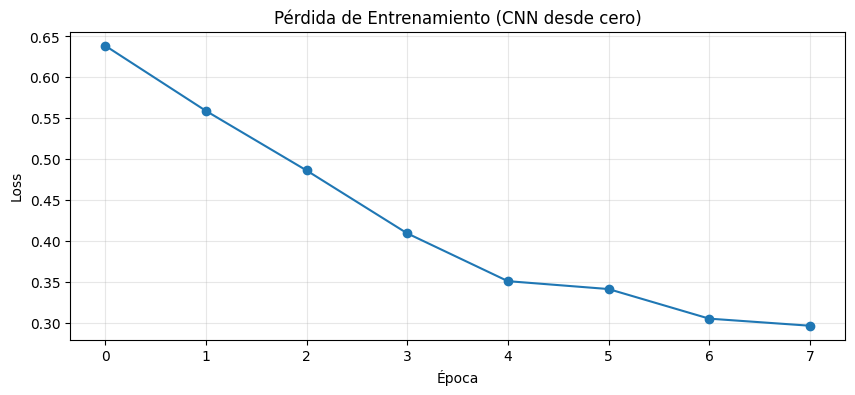

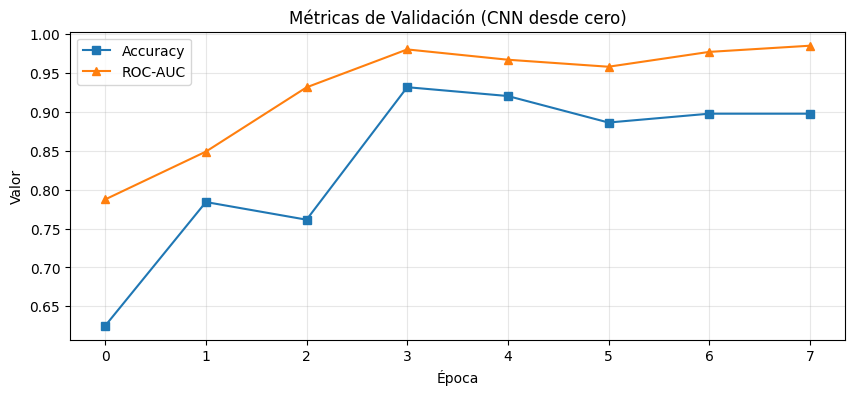

In [ ]:
# Gráfico de la función de pérdida a lo largo de las épocas
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], marker="o")
plt.title("Pérdida de Entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("CrossEntropy Loss")
plt.grid(True, alpha=0.3)
plt.show()

# Gráfico de evolución de Accuracy y ROC-AUC en el conjunto de validación
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy", marker="s")
plt.plot(history_scratch["val_auc"], label="ROC-AUC", marker="^")
plt.title("Métricas de Validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Test Accuracy: 0.9333
Test ROC-AUC:  0.9847
Brier Score:   0.0564

                 precision    recall  f1-score   support

jugada_dividida     0.9348    0.9348    0.9348        46
           tiro     0.9318    0.9318    0.9318        44

       accuracy                         0.9333        90
      macro avg     0.9333    0.9333    0.9333        90
   weighted avg     0.9333    0.9333    0.9333        90



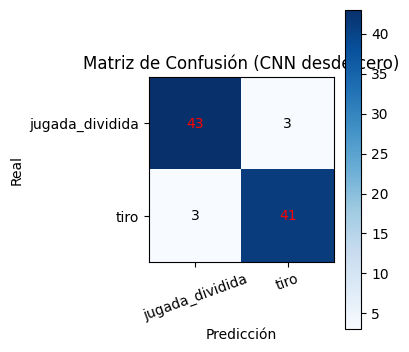

In [ ]:
test_acc, test_auc, test_brier, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print(f"Brier Score:   {test_brier:.4f}\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Construir matriz de confusión 2x2 para evaluar falsos positivos y falsos negativos
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de Confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1], class_names, rotation=20)
plt.yticks([0, 1], class_names)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
# Aumento de datos: rotaciones ligeras, espejo horizontal y variaciones de iluminación
transform_aug = T.Compose([
    T.Resize((128, 128)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Aplicar las transformaciones únicamente al subconjunto de entrenamiento
dataset_aug = ImageFolder(root="dataset_futbol_binario", transform=transform_aug)
train_sub_aug = torch.utils.data.Subset(dataset_aug, train_dataset.indices)
train_loader_aug = DataLoader(train_sub_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# Entrenar una red gemela idéntica para aislar el efecto de las transformaciones
model_aug = SoccerActionCNN(num_classes=num_classes).to(device)
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_aug = CosineAnnealingLR(optimizer_aug, T_max=6, eta_min=1e-5)

for epoch in range(1, 7):
    loss = train_one_epoch(model_aug, train_loader_aug, optimizer_aug, criterion)
    val_acc_a, val_auc_a, _, _, _, _ = evaluate(model_aug, val_loader)
    scheduler_aug.step()
    print(f"Aug Epoch {epoch:02d} | Loss: {loss:.4f} | Val Acc: {val_acc_a:.4f} | Val AUC: {val_auc_a:.4f}")

# Comparar desempeño sobre el mismo conjunto de test
test_acc_aug, test_auc_aug, _, _, _, _ = evaluate(model_aug, test_loader)
print("\n--- Comparación en Test ---")
print(f"Sin Data Augmentation | Acc: {test_acc:.4f} | AUC: {test_auc:.4f}")
print(f"Con Data Augmentation | Acc: {test_acc_aug:.4f} | AUC: {test_auc_aug:.4f}")

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Aug Epoch 01 | Loss: 0.6244 | Val Acc: 0.7386 | Val AUC: 0.7822


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Aug Epoch 02 | Loss: 0.5727 | Val Acc: 0.7727 | Val AUC: 0.8156


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Aug Epoch 04 | Loss: 0.4730 | Val Acc: 0.7500 | Val AUC: 0.9014


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Aug Epoch 05 | Loss: 0.4515 | Val Acc: 0.8523 | Val AUC: 0.9364


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Aug Epoch 06 | Loss: 0.4309 | Val Acc: 0.8750 | Val AUC: 0.9518

--- Comparación en Test ---
Sin Data Augmentation | Acc: 0.9333 | AUC: 0.9847
Con Data Augmentation | Acc: 0.9333 | AUC: 0.9788


In [ ]:
import torchvision.models as models

# ResNet-18 fue entrenada con imágenes de 224x224
transform_tl = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset_tl = ImageFolder(root="dataset_futbol_binario", transform=transform_tl)
train_loader_tl = DataLoader(torch.utils.data.Subset(dataset_tl, train_dataset.indices), batch_size=32, shuffle=True)
val_loader_tl   = DataLoader(torch.utils.data.Subset(dataset_tl, val_dataset.indices), batch_size=32, shuffle=False)
test_loader_tl  = DataLoader(torch.utils.data.Subset(dataset_tl, test_dataset.indices), batch_size=32, shuffle=False)

# Cargar pesos preentrenados de ImageNet
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Congelar todo el extractor de características para no borrar lo aprendido
for param in resnet.parameters():
    param.requires_grad = False

# Reemplazar la última capa lineal (fc) para clasificar solo nuestras 2 clases
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet = resnet.to(device)

# Etapa 1: Entrenar únicamente la cabeza clasificadora (Feature Extraction)
optimizer_tl = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)
for epoch in range(1, 5):
    loss = train_one_epoch(resnet, train_loader_tl, optimizer_tl, criterion)
    val_acc_t, val_auc_t, _, _, _, _ = evaluate(resnet, val_loader_tl)
    print(f"Stage 1 Epoch {epoch:02d} | Loss: {loss:.4f} | Val Acc: {val_acc_t:.4f}")

# Etapa 2: Fine-Tuning: Descongelar el último bloque convolucional (layer4) con un learning rate menor
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

optimizer_ft = torch.optim.Adam([p for p in resnet.parameters() if p.requires_grad], lr=1e-4)
for epoch in range(1, 5):
    loss = train_one_epoch(resnet, train_loader_tl, optimizer_ft, criterion)
    val_acc_t, val_auc_t, _, _, _, _ = evaluate(resnet, val_loader_tl)
    print(f"Stage 2 (Fine-Tuning) Epoch {epoch:02d} | Loss: {loss:.4f} | Val Acc: {val_acc_t:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 217MB/s]
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Stage 1 Epoch 01 | Loss: 0.6511 | Val Acc: 0.7614


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Stage 1 Epoch 02 | Loss: 0.4143 | Val Acc: 0.9205


...

Stage 2 (Fine-Tuning) Epoch 02 | Loss: 0.0264 | Val Acc: 0.9886


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Stage 2 (Fine-Tuning) Epoch 03 | Loss: 0.0136 | Val Acc: 0.9886


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Stage 2 (Fine-Tuning) Epoch 04 | Loss: 0.0043 | Val Acc: 1.0000


In [ ]:
test_acc_tl, test_auc_tl, test_brier_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)

print("===== RESUMEN DE MODELOS EN TEST =====")
print(f"CNN desde cero (Sin Aug)  | Acc: {test_acc:.4f} | AUC: {test_auc:.4f}")
print(f"CNN desde cero (Con Aug)  | Acc: {test_acc_aug:.4f} | AUC: {test_auc_aug:.4f}")
print(f"Transfer Learning (ResNet)| Acc: {test_acc_tl:.4f} | AUC: {test_auc_tl:.4f} | Brier: {test_brier_tl:.4f}")

===== RESUMEN DE MODELOS EN TEST =====
CNN desde cero (Sin Aug)  | Acc: 0.9333 | AUC: 0.9847
CNN desde cero (Con Aug)  | Acc: 0.9333 | AUC: 0.9788
Transfer Learning (ResNet)| Acc: 0.9556 | AUC: 0.9995 | Brier: 0.0301


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


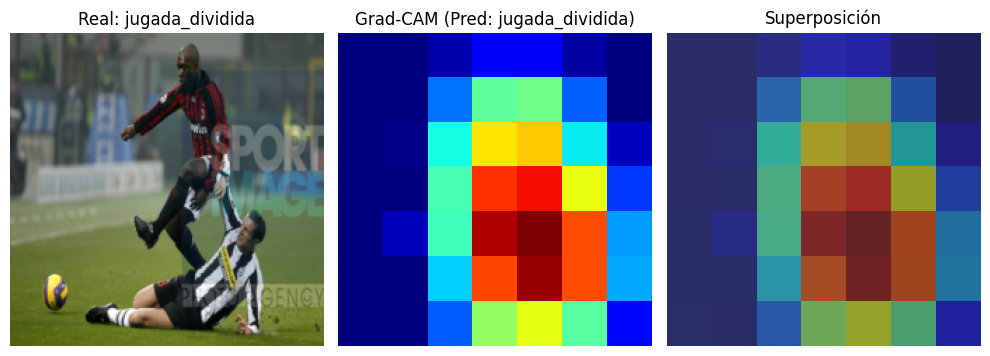

In [ ]:
def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device).unsqueeze(0)
    activations, gradients = {}, {}

    # Hooks para interceptar activaciones y gradientes en la última capa convolucional
    def forward_hook(module, inp, out):
        activations["value"] = out
    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    h_fwd = model.layer4.register_forward_hook(forward_hook)
    h_bwd = model.layer4.register_full_backward_hook(backward_hook)

    # Paso hacia adelante
    logits = model(image_tensor)
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    # Paso hacia atrás dirigido solo a la clase ganadora
    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    # Ponderar los mapas de activación según la importancia de sus gradientes
    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    # ReLU para mantener solo las características con impacto positivo
    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    # Retirar los hooks para liberar memoria
    h_fwd.remove()
    h_bwd.remove()
    return cam.detach().cpu().numpy(), target_class

# Extraer el primer ejemplo de test y calcular su mapa de calor
sample_x, sample_y = test_loader_tl.dataset[0]
cam_map, pred_class = grad_cam(resnet, sample_x)

inv_norm = T.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
img_rgb = inv_norm(sample_x).permute(1, 2, 0).clamp(0, 1).cpu().numpy()

# Mostrar la imagen original, el mapa de calor y la superposición
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title(f"Real: {class_names[sample_y]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam_map, cmap="jet")
plt.title(f"Grad-CAM (Pred: {class_names[pred_class]})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_rgb)
plt.imshow(cam_map, cmap="jet", alpha=0.5)
plt.title("Superposición")
plt.axis("off")
plt.tight_layout()
plt.show()

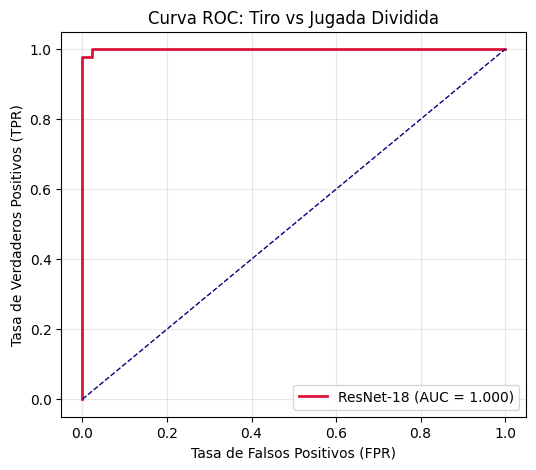

Brier Score (ResNet-18): 0.0301
Nota: Un Brier Score cercano a 0 indica alta fiabilidad probabilística del modelo.


In [ ]:
from sklearn.metrics import roc_curve, auc

# Calcular las tasas de verdaderos y falsos positivos variando el umbral de decisión
fpr, tpr, _ = roc_curve(y_true_tl, y_prob_tl)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="crimson", lw=2, label=f"ResNet-18 (AUC = {roc_auc_val:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")  # Línea base aleatoria
plt.title("Curva ROC: Tiro vs Jugada Dividida")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Imprimir el error cuadrático medio de las probabilidades predichas
print(f"Brier Score (ResNet-18): {test_brier_tl:.4f}")
print("Nota: Un Brier Score cercano a 0 indica que las probabilidades del modelo son fiables y no están descalibradas.")